In [2]:
from urllib import parse
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")



In [3]:
#read the file
data=pd.read_csv("Housing.csv")
data.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
#performing EDA on the dataset
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


In [5]:
data.shape

(545, 13)

In [6]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
data.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [8]:
data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [9]:
#segregating numerical and categorical columns
numerical_col=['price','area','bedrooms','bathrooms','stories','parking']



<Axes: >

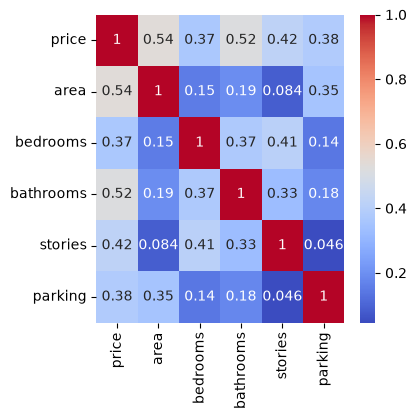

In [10]:
#plotting the correlation matrix
plt.figure(figsize=(4,4))
sns.heatmap(data[numerical_col].corr(), annot=True, cmap="coolwarm")

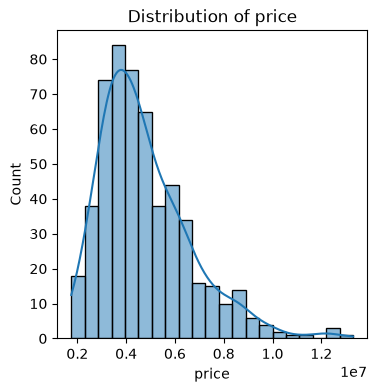

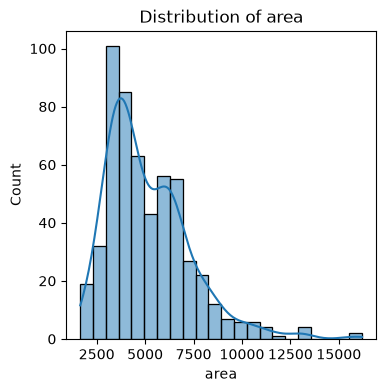

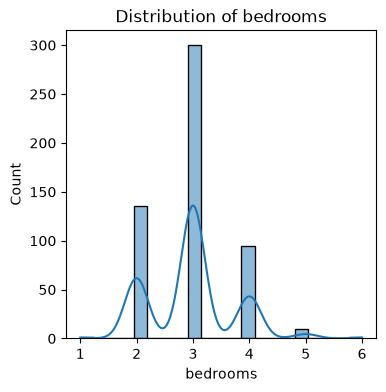

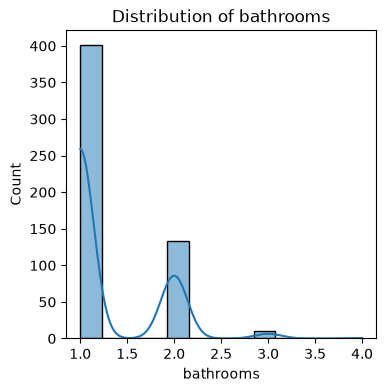

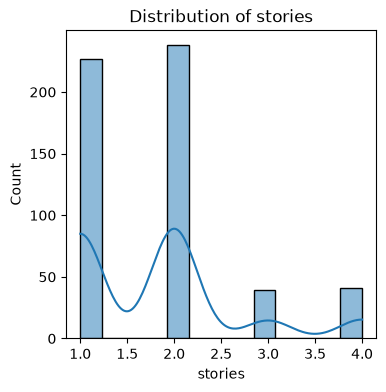

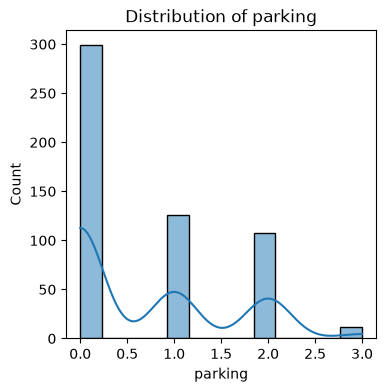

In [11]:
#histplot for numerical columns
for i in numerical_col:
    plt.figure(figsize=(4,4))
    sns.histplot(data[i], kde=True)
    plt.title(f"Distribution of {i}")
    plt.show()

In [12]:
#data cleaning and preprocessing
clean_data=data.copy()
clean_data.dropna(inplace=True)
clean_data.reset_index(drop=True, inplace=True)
clean_data.drop_duplicates(inplace=True)
clean_data.shape
clean_data.isnull().sum()
clean_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


In [13]:
clean_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [14]:
categorical_col = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

In [15]:
print(clean_data.columns.tolist())

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [16]:
print(clean_data['furnishingstatus'].unique())

<ArrowStringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str


In [17]:
clean_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [18]:
clean_data = pd.get_dummies(
    clean_data,
    columns=['furnishingstatus'],
    drop_first=True
)


In [19]:
clean_data.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,False,False
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,False,False
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,True,False
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,False,False
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,False,False


In [22]:
print(clean_data.select_dtypes(include='object').head())
print(clean_data.select_dtypes(include='object').nunique())

  mainroad guestroom basement hotwaterheating airconditioning prefarea
0      yes        no       no              no             yes      yes
1      yes        no       no              no             yes       no
2      yes        no      yes              no              no      yes
3      yes        no      yes              no             yes      yes
4      yes       yes      yes              no             yes       no
mainroad           2
guestroom          2
basement           2
hotwaterheating    2
airconditioning    2
prefarea           2
dtype: int64


In [23]:
clean_data = clean_data.replace({
    'yes': 1,
    'no': 0,
    True: 1,
    False: 0
})

clean_data = clean_data.astype(int)

In [24]:
clean_data.info()


<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    int64
 13  f

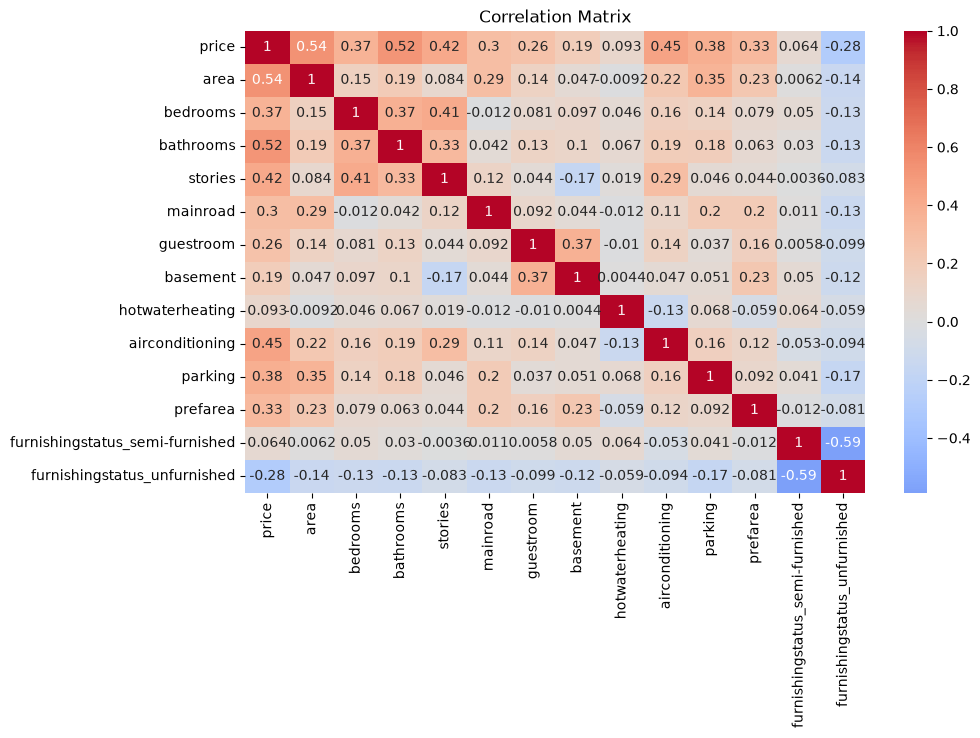

In [25]:
#do the feature selection using correlation matrix
fig = plt.figure(figsize=(10, 6))
sns.heatmap(clean_data.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()


In [26]:
#do the feature scaling using standard scaler

from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
clean_data_scaled = scaler.fit_transform(clean_data)

In [27]:
clean_data_scaled = pd.DataFrame(clean_data_scaled, columns=clean_data.columns)
clean_data_scaled.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,4.566365,1.046726,1.403419,1.421812,1.378217,0.405623,-0.465315,-0.734539,-0.219265,1.472618,1.517692,1.804941,-0.844888,-0.696429
1,4.004484,1.757010,1.403419,5.405809,2.532024,0.405623,-0.465315,-0.734539,-0.219265,1.472618,2.679409,-0.554035,-0.844888,-0.696429
2,4.004484,2.218232,0.047278,1.421812,0.224410,0.405623,-0.465315,1.361397,-0.219265,-0.679063,1.517692,1.804941,1.183588,-0.696429
3,3.985755,1.083624,1.403419,1.421812,0.224410,0.405623,-0.465315,1.361397,-0.219265,1.472618,2.679409,1.804941,-0.844888,-0.696429
4,3.554979,1.046726,1.403419,-0.570187,0.224410,0.405623,2.149083,1.361397,-0.219265,1.472618,1.517692,-0.554035,-0.844888,-0.696429


In [29]:
from urllib.parse import urlparse
x=clean_data_scaled.drop('price', axis=1)
y=clean_data_scaled['price']

In [30]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [31]:
#param_grid parameters for hyperparameter tuning
param_grid={'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7], 'min_samples_split': [2, 5, 10]}

In [34]:
#hyperpameter tuning using grid search cv
def hyperparameter_tuning(model, param_grid, x_train, y_train):
    from sklearn.model_selection import GridSearchCV
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
    grid_search.fit(x_train, y_train)
    return grid_search


In [35]:
#mlflow tracking for model training and evaluation

from mlflow.models import infer_signature
signature=infer_signature(x_train,y_train)


In [40]:
#start with mlflow experiments
import mlflow
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("Car_Price_Prediction_Experiment")
with mlflow.start_run():
    grid_search = hyperparameter_tuning(RandomForestRegressor(), param_grid, x_train, y_train)
    model=grid_search.best_estimator_


    y_pred=model.predict(x_test)
    mse=mean_squared_error(y_test, y_pred)
    accuracy=model.score(x_test,y_test)*100
    mae=mean_absolute_error(y_test,y_pred)
    r2=r2_score(y_test,y_pred)

    mlflow.log_param("best_n_estimators",grid_search.best_params_['n_estimators'])
    mlflow.log_param("best_max_depth", grid_search.best_params_['max_depth'])
    mlflow.log_param("best_min_samples_split", grid_search.best_params_['min_samples_split'])
    mlflow.log_metric("mse",mse)
    mlflow.log_metric("mae",mae)
    mlflow.log_metric("r2",r2)

    tracking_url_store=urlparse(mlflow.get_tracking_uri()).scheme

    if tracking_url_store != "file":
        mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="model",
        registered_model_name="best_carpridiction_model",
        skops_trusted_types=["sklearn.tree._tree.Tree"]
    )
    else:
        mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="model",
        signature=signature,
        skops_trusted_types=["sklearn.tree._tree.Tree"]
    )

print("Model logged to MLflow")

Fitting 5 folds for each of 27 candidates, totalling 135 fits


2026/10/09 20:19:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'best_carpridiction_model'.
2026/10/09 20:19:33 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: best_carpridiction_model, version 1
Created version '1' of model 'best_carpridiction_model'.


🏃 View run calm-roo-427 at: http://localhost:5000/#/experiments/1/runs/715cfd0e64d142819fdff829d071e491
🧪 View experiment at: http://localhost:5000/#/experiments/1
Model logged to MLflow
